In [1]:
# ============================================================
# 🚀 FULL HIGH-ACCURACY SOLAR MODEL (FINAL)
# ============================================================

import os, json, zipfile, shutil
import numpy as np
import tensorflow as tf

# ============================================================
# 🚀 GPU SETUP
# ============================================================
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError("❌ GPU NOT DETECTED")

tf.config.set_visible_devices(gpus[0], 'GPU')

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

tf.keras.mixed_precision.set_global_policy("mixed_float16")

AUTO = tf.data.AUTOTUNE
SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("✅ GPU Ready:", gpus)

# ============================================================
# 📂 LOAD DATA
# ============================================================
DATA_DIR = "/kaggle/input/new-solar-ds/dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
VAL_SPLIT = 0.2

class_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

filepaths, labels = [], []

for idx, cn in enumerate(class_names):
    for root, _, files in os.walk(os.path.join(DATA_DIR, cn)):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                filepaths.append(os.path.join(root, f))
                labels.append(idx)

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))

# ============================================================
# 🔀 SPLIT
# ============================================================
rng = np.random.default_rng(SEED)

train_idx, val_idx = [], []

for c in range(len(class_names)):
    c_idx = np.where(labels == c)[0]
    rng.shuffle(c_idx)

    cut = int(len(c_idx) * (1 - VAL_SPLIT))
    train_idx.extend(c_idx[:cut])
    val_idx.extend(c_idx[cut:])

X_train, y_train = filepaths[train_idx], labels[train_idx]
X_val, y_val = filepaths[val_idx], labels[val_idx]

# ============================================================
# ⚙️ DATA PIPELINE
# ============================================================
from tensorflow.keras.applications import mobilenet_v3

def make_ds(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(paths), seed=SEED)

    def decode(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMG_SIZE)

        if training:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.2)
            img = tf.image.random_contrast(img, 0.8, 1.2)

        img = tf.cast(img, tf.float32)
        img = mobilenet_v3.preprocess_input(img)

        dust = tf.where(label == 1, 8.0, 1.0)

        return img, {"cls": label, "dust": dust}

    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    return ds

# ✅ CREATE DATASETS
train_ds = make_ds(X_train, y_train, True)
val_ds = make_ds(X_val, y_val, False)

# ============================================================
# 🧠 MODEL
# ============================================================
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large

def build_model():
    base = MobileNetV3Large(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3),
        pooling="avg"
    )

    # Freeze all layers first
    for layer in base.layers:
        layer.trainable = False

    # Unfreeze top layers
    for layer in base.layers[-40:]:
        layer.trainable = True

    inp = layers.Input((224,224,3))
    x = base(inp)

    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # FLOAT32 OUTPUT (IMPORTANT)
    cls = layers.Dense(1, activation="sigmoid", dtype="float32", name="cls")(x)

    dust = layers.Dense(1, activation="sigmoid")(x)
    dust = layers.Lambda(lambda x: 9*x + 1, name="dust", dtype="float32")(dust)

    return models.Model(inp, {"cls": cls, "dust": dust})

model = build_model()

# ============================================================
# ⚡ COMPILE
# ============================================================
from tensorflow.keras.optimizers import AdamW

model.compile(
    optimizer=AdamW(learning_rate=3e-4),
    loss={
        "cls": tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        "dust": "mae"
    },
    loss_weights={"cls": 1.0, "dust": 0.3},
    metrics={
        "cls": ["accuracy", tf.keras.metrics.AUC()],
        "dust": ["mae"]
    }
)

# ============================================================
# 📊 TRAIN
# ============================================================
from tqdm.keras import TqdmCallback

callbacks = [
    TqdmCallback(verbose=1),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_cls_accuracy",
        factor=0.3,
        patience=2,
        mode="max"   # ✅ FIXED
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_cls_accuracy",
        patience=6,
        restore_best_weights=True,
        mode="max"   # ✅ FIXED
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=0
)


# ============================================================
# 💾 SAVE
# ============================================================
MODEL_PATH = "/kaggle/working/solar_model.keras"
model.save(MODEL_PATH)

with open("/kaggle/working/class_index.json", "w") as f:
    json.dump({i:c for i,c in enumerate(class_names)}, f)

# ============================================================
# 📦 EXPORT
# ============================================================
EXPORT_DIR = "/kaggle/working/export"
os.makedirs(EXPORT_DIR, exist_ok=True)

shutil.copy(MODEL_PATH, EXPORT_DIR)
shutil.copy("/kaggle/working/class_index.json", EXPORT_DIR)

zip_path = "/kaggle/working/solar_project.zip"

with zipfile.ZipFile(zip_path, 'w') as z:
    for root, _, files in os.walk(EXPORT_DIR):
        for file in files:
            z.write(os.path.join(root, file), file)

print("✅ DOWNLOAD READY:", zip_path)

2026-04-14 16:47:36.860504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776185257.070001      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776185257.137451      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ GPU Ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Total images: 33670


I0000 00:00:1776185315.935612      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

I0000 00:00:1776185337.365943      99 service.cc:148] XLA service 0x7f6e08002740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776185337.367098      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776185339.832505      99 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1776185353.784478      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


✅ DOWNLOAD READY: /kaggle/working/solar_project.zip


bench marking

🔄 Generating predictions for validation set...

✅ Final Accuracy: 0.9923
✅ Final F1 Score: 0.9926

📋 Detailed Classification Report:
              precision    recall  f1-score   support

       Clean       0.99      0.99      0.99      3209
       Dusty       0.99      0.99      0.99      3526

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



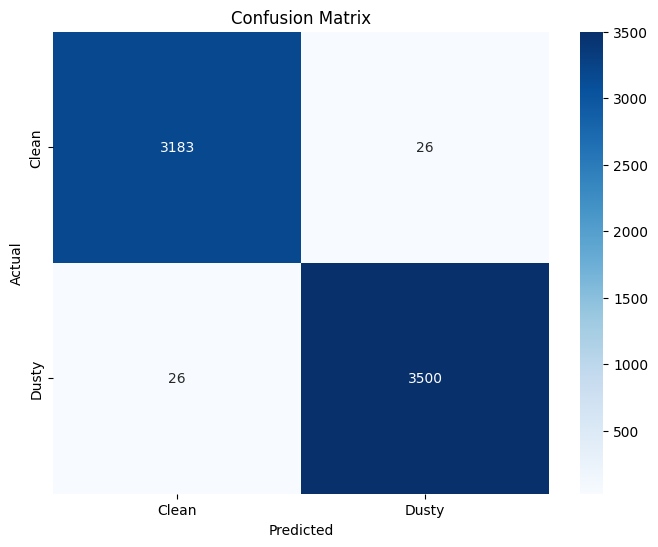

In [2]:
import numpy as np
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get True Labels and Predictions
y_true = []
y_pred_probs = []

print("🔄 Generating predictions for validation set...")
for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    
    # Extract the 'cls' (classification) output
    # Since it's a sigmoid output, it returns a probability
    y_pred_probs.extend(preds['cls'].flatten())
    y_true.extend(labels['cls'].numpy().flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# 2. Convert probabilities to binary (0 or 1) using 0.5 threshold
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# 3. Calculate Metrics
acc = accuracy_score(y_true, y_pred_binary)
f1 = f1_score(y_true, y_pred_binary)

print("\n" + "="*30)
print(f"✅ Final Accuracy: {acc:.4f}")
print(f"✅ Final F1 Score: {f1:.4f}")
print("="*30 + "\n")

# 4. Detailed Classification Report
print("📋 Detailed Classification Report:")
print(classification_report(y_true, y_pred_binary, target_names=class_names))

# 5. Visual Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [4]:
import pickle

# Path to save the pickle file
PKL_PATH = "/kaggle/working/solar_model.pkl"

# Save the model object using pickle
with open(PKL_PATH, 'wb') as f:
    pickle.dump(model, f)

print(f"✅ Model successfully pickled to: {PKL_PATH}")

✅ Model successfully pickled to: /kaggle/working/solar_model.pkl
